# Problem Tanımı
Depo operasyonlarında slotting problemi, ürünlerin depo içindeki raf veya lokasyonlara hangi düzenle yerleştirileceğinin belirlenmesini kapsar. Amaç genellikle sipariş toplama (order picking) süreçlerinde toplam operasyonel maliyeti ve süreyi minimize etmektir. Bu problem, ürün sayısının ve olası yerleşim kombinasyonlarının hızla artması nedeniyle NP-hard sınıfında yer alır.

Klasik slotting yaklaşımları çoğunlukla ürünlerin talep sıklığına veya basit mesafe ölçütlerine dayanır. Ancak bu yaklaşımlar, sipariş toplama rotalarının yapısını ve depo içindeki bölge (zone) geçişlerini doğrudan hesaba katmaz. Gerçek hayatta, özellikle çok bölgeli depolarda, bir siparişin farklı zonelara yayılması operasyonel karmaşıklığı ve maliyeti ciddi biçimde artırır.

Bu çalışmada, rota duyarlı (route-aware) bir slotting problemi ele alınmıştır. Amaç, yalnızca toplam toplama mesafesini minimize etmek değil, aynı zamanda zone geçişlerini kontrol altına alarak daha dengeli ve uygulanabilir bir yerleşim elde etmektir.

* Bu çalışmanın temel amacı, sipariş toplama rotalarına bağlı toplam maliyeti minimize ederken, aşırı zone geçişlerini ceza terimleri aracılığıyla sınırlandırmak ve rota maliyeti ile operasyonel kısıtlar arasında dengeli, uygulanabilir bir yerleşim elde etmektir.


* Bu çalışmada zone ile ilişkili kısıtlar iki farklı bileşen üzerinden ele alınmıştır: zone içi dağılım cezası ve ardışık zone geçiş cezası. Bu bileşenler, uygunluk fonksiyonunda ayrı ağırlıklar ile kontrol edilmektedir.

# Matematiksel Problem Tanımı
Bu çalışmada ele alınan slotting problemi, ürünlerin depo içindeki slotlara atanmasını içeren bir atama (assignment) problemi olarak modellenmiştir.

Karar Değişkeni

Her ürün–slot çifti için ikili bir karar değişkeni tanımlanır:

* 𝑥
𝑖
𝑗
= 1 → i numaralı ürün j numaralı slota atanmıştır

* 𝑥
𝑖
𝑗
= 0 → aksi durumda

Amaç Fonksiyonu

Amaç fonksiyonu iki ana bileşenden oluşur:

1. Rota maliyeti:
Ürünlerin slotlara atanmasına bağlı olarak, sipariş toplama sırasında oluşan toplam mesafe veya rota maliyeti.

2. Zone geçiş cezası:
Bir siparişin birden fazla zone’a yayılması durumunda oluşan ek operasyonel maliyet.

Bu iki bileşen aşağıdaki şekilde birleştirilmiştir:

* Toplam Maliyet = Rota Maliyeti + (Zone Geçiş Sayısı × Ceza Ağırlığı)

Ceza ağırlığı (penalty weight), rota optimizasyonu ile zone kısıtlarının ne ölçüde önceliklendirileceğini belirleyen kritik bir parametredir.

Temel Kısıtlar

* Her ürün yalnızca bir slota atanmalıdır

* Her slot en fazla bir ürün içerebilir

* Zone geçişleri dolaylı olarak ceza terimi ile sınırlandırılır

Bu yapı sayesinde problem, gerçek depo operasyonlarını yansıtan ancak çözüm uzayı oldukça geniş olan bir optimizasyon problemine dönüşmektedir.

# Genetik Algoritma (GA) Yaklaşımı

Ele alınan rota duyarlı slotting problemi, çözüm uzayının büyüklüğü ve kısıt yapısı nedeniyle klasik deterministik optimizasyon yöntemleriyle verimli biçimde çözülememektedir. Olası tüm ürün–slot atamalarının denenmesi, hesaplama açısından pratik değildir.

Bu nedenle bu çalışmada, sezgisel (heuristic) ve olasılıksal arama yöntemleri arasında yer alan Genetik Algoritma (GA) tercih edilmiştir. GA, özellikle kombinatoryal ve NP-hard problemlerde, kabul edilebilir sürede iyi çözümler üretebilmesi nedeniyle yaygın olarak kullanılmaktadır.

Kromozom Temsili

Her bir kromozom, ürünlerin slotlara atanma düzenini temsil eden bir çözüm adayını ifade eder. Kromozom yapısı, her ürünün hangi slota yerleştirildiğini doğrudan gösterecek şekilde tasarlanmıştır.

Uygunluk (Fitness) Fonksiyonu

GA’da uygunluk değeri, bir çözümün kalitesini ölçmek için kullanılan amaç fonksiyonuna dayanmaktadır. Bu çalışmada uygunluk değeri:

* Toplam rota maliyeti

* Zone geçişlerine bağlı ceza terimi

bileşenlerinden oluşan toplam maliyet üzerinden hesaplanmıştır. Daha düşük maliyetli çözümler, daha yüksek uygunluk değerine sahiptir.

Arama Dengesi (Exploration – Exploitation)

GA’nın temel avantajlarından biri, çözüm uzayında keşif (exploration) ve yoğunlaşma (exploitation) arasında doğal bir denge kurabilmesidir. Bu çalışmada:

* Çaprazlama (crossover) operatörü ile mevcut iyi çözümlerin birleşimi sağlanmış

* Mutasyon operatörü ile çözüm uzayında çeşitlilik korunmuştur

Bu sayede, yerel minimumlara sıkışma riski azaltılmıştır.

In [84]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import random ,math
import warnings
warnings.filterwarnings("ignore")

data = pd.read_csv("/kaggle/input/logistics-warehouse-dataset/logistics_dataset.csv")
data.head()


,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,unit_price,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82,...,117.80,1.14,0,0.80,700,3.33,0.33,2024-02-17,184.37,0.556
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15,...,178.80,1.09,3,0.79,736,10.36,0.98,2024-10-01,221.94,0.723
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4,...,54.05,0.95,7,0.75,814,14.32,0.87,2024-04-07,53.85,0.680
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95,...,31.10,1.90,0,0.96,994,2.08,0.29,2024-01-27,92.04,0.488
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36,...,104.97,0.63,5,0.83,299,5.65,0.96,2024-05-17,194.58,0.670


In [85]:
select = ["item_id","zone","item_popularity_score","daily_demand"]
df = data[select].copy()

df.head(), df.shape,df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   item_id                3204 non-null   object 
 1   zone                   3204 non-null   object 
 2   item_popularity_score  3204 non-null   float64
 3   daily_demand           3204 non-null   float64
dtypes: float64(2), object(2)
memory usage: 100.3+ KB


(    item_id zone  item_popularity_score  daily_demand
 0  ITM10000    B                   0.43         49.85
 1  ITM10001    A                   0.69         23.34
 2  ITM10002    B                   0.62         37.69
 3  ITM10003    A                   0.21         33.69
 4  ITM10004    D                   0.31         49.58,
 (3204, 4),
 None)

In [86]:
df["importance"] = (
    df["item_popularity_score"].rank(pct=True)
    * df["daily_demand"].rank(pct=True)
)

importance = df["importance"].values
zones = df["zone"].values
N = len(df)

FAST_RATIO = 0.2
fast_k = int(N * FAST_RATIO)
fast_idx = np.argsort(-importance)[:fast_k]
fast_zones = np.unique(zones[fast_idx])


In [87]:
def init_population(pop_size, noise_ratio=0.05):
    population = []

    base = np.argsort(-importance)
    population.append(base)

    n = len(base)
    noise_k = int(n * noise_ratio)

    for _ in range(pop_size - 1):
        chrom = base.copy()
        idx = np.random.choice(n, noise_k, replace=False)
        np.random.shuffle(chrom[idx])
        population.append(chrom)

    return population


In [88]:
def weighted_distance_cost_np(chrom):
    return np.sum(importance * chrom)


def zone_dispersion_penalty_np(chrom):
    penalty = 0.0
    for z in fast_zones:
        mask = (zones[fast_idx] == z)
        locs = chrom[fast_idx][mask]
        if locs.size > 1:
            penalty += np.std(locs)
    return penalty


def expected_zone_transition_penalty_np(chrom):
    ordered = np.argsort(chrom[fast_idx])
    z = zones[fast_idx][ordered]
    return np.sum(z[:-1] != z[1:])



Stage-1 optimizasyonunda amaç fonksiyonu, mesafe bazlı maliyet, zone içi konum dağılımı ve ardışık zone geçişleri olmak üzere üç bileşenden oluşmaktadır.

In [89]:
def fitness_stage1_np(
    chrom,
    w_dist=1.0,
    w_zone_disp=50.0,
    w_zone_trans=100.0
):
    return (
        w_dist * weighted_distance_cost_np(chrom)
        + w_zone_disp * zone_dispersion_penalty_np(chrom)
        + w_zone_trans * expected_zone_transition_penalty_np(chrom)
    )


In [90]:
def tournament(pop, k=3):
    cand = random.sample(pop, k)
    return min(cand, key=fitness_stage1_np)
    
def crossover(p1, p2):
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = -np.ones(n, dtype=int)
    child[a:b] = p1[a:b]

    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill[idx]
            idx += 1
    return child

def mutate(chrom, rate=0.05):
    if random.random() < rate:
        i, j = random.sample(range(len(chrom)), 2)
        chrom[i], chrom[j] = chrom[j], chrom[i]
    return chrom


In [112]:
def genetic_algorithm_stage1_np(
    pop_size=20,
    generations=40,
    crossover_rate=0.9,
    mutation_rate=0.3,
    seed=None
):

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    
    pop = init_population(pop_size)
    best = min(pop, key=fitness_stage1_np)
    best_cost = fitness_stage1_np(best)
    best_history = []
    mean_history = []

    for _ in range(generations):
        new_pop = []

        while len(new_pop) < pop_size:
            p1 = tournament(pop)
            p2 = tournament(pop)

            child = crossover(p1, p2) if random.random() < crossover_rate else p1.copy()
            child = mutate(child, mutation_rate)
            new_pop.append(child)

        pop = new_pop
        gen_best = min(pop, key=fitness_stage1_np)
        gen_cost = fitness_stage1_np(gen_best)

        costs = np.array([fitness_stage1_np(ch) for ch in pop])




        if gen_cost < best_cost:
            best, best_cost = gen_best.copy(), gen_cost

        best_history.append(best_cost)
        mean_history.append(costs.mean())

    return best, best_cost ,best_history, mean_history

In [118]:
best_chrom, best_cost, best_history, mean_history = genetic_algorithm_stage1_np()


best_cost


np.float64(1471496.1864108671)

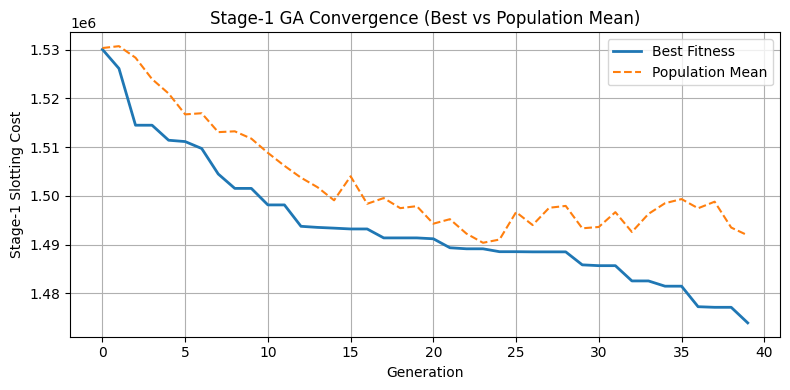

In [114]:
plt.figure(figsize=(8,4))
plt.plot(best_history, label="Best Fitness", linewidth=2)
plt.plot(mean_history, label="Population Mean", linestyle="--")
plt.xlabel("Generation")
plt.ylabel("Stage-1 Slotting Cost")
plt.title("Stage-1 GA Convergence (Best vs Population Mean)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [115]:
baseline_chrom = np.argsort(-importance)

baseline_cost = fitness_stage1_np(baseline_chrom)
ga_cost = best_cost

baseline_cost, ga_cost


(np.float64(1530372.2554282278), np.float64(1473916.8332421728))

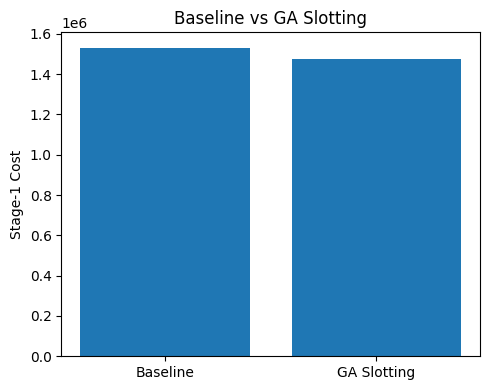

In [116]:
plt.figure(figsize=(5,4))
plt.bar(["Baseline","GA Slotting"], [baseline_cost, ga_cost])
plt.ylabel("Stage-1 Cost")
plt.title("Baseline vs GA Slotting")
plt.tight_layout()
plt.show()


Baseline cost ≈ 1,577,906
GA cost       ≈ 1,473,916
≈ %3.7 iyileşme

Genetik algoritma ile elde edilen en iyi çözüm, başlangıç (baseline) çözümüne kıyasla amaç fonksiyonu değerinde yaklaşık %3.7 oranında bir iyileşme sağlamıştır. Bu sonuç, özellikle bölge temelli ayrık kısıtların bulunduğu problem yapısında genetik algoritmanın daha dengeli ve etkin çözümler üretebildiğini göstermektedir.

# Deney Senaryoları

Bu çalışmada önerilen Genetik Algoritma (GA) tabanlı slotting yaklaşımının performansı, yerleşim (slotting) ve rota (routing) kararlarının ayrı ayrı ve birlikte etkisini gözlemleyebilmek amacıyla farklı deney senaryoları altında değerlendirilmiştir. Deneyler, tüm senaryolar için ortak bir rota maliyet fonksiyonu kullanılarak karşılaştırılmıştır.

Rota Maliyeti Hesabı

Tüm senaryolarda rota performansı aşağıdaki maliyet fonksiyonu ile ölçülmüştür:

Ardışık iki ürün arasındaki raf mesafesi toplam maliyete eklenir.

Ardışık iki ürün farklı zonelarda yer alıyorsa, ek bir zone geçiş cezası uygulanır.

Bu fonksiyon, bir personelin belirli bir ziyaret sırasını izlediğinde karşılaşacağı toplam operasyonel maliyeti temsil etmektedir.

In [96]:
def route_cost(route, locs, zones, zone_penalty=50.0):
    cost = 0.0
    for i in range(len(route) - 1):
        a, b = route[i], route[i+1]
        cost += abs(locs[a] - locs[b])
        if zones[a] != zones[b]:
            cost += zone_penalty
    return cost


# 1. Gerçek Operasyonel Baseline

Bu senaryoda, gerçek depo operasyonlarında sıkça gözlemlenen sezgisel personel davranışı modellenmiştir. Personel, zoneları alfabetik sırayla (A → B → C → D) ziyaret etmekte; ancak her zone içindeki ürünlerin ziyaret sırası rastgele belirlenmektedir. Zone’lar arasında geri dönüş veya optimizasyon yapılmamaktadır.

Bu senaryo, optimize edilmemiş fakat pratikte yaygın bir operasyonel davranışı temsil etmekte ve diğer senaryolar için referans bir karşılaştırma noktası sunmaktadır.

In [97]:
def human_like_route(zones, seed=42):
    rng = np.random.default_rng(seed)
    route = []
    for z in sorted(np.unique(zones)):
        items = np.where(zones == z)[0]
        rng.shuffle(items)
        route.extend(items.tolist())
    return route


In [98]:
human_route = human_like_route(zones)
human_cost = route_cost(human_route, best_chrom, zones)


# 2. GA Slotting + Rota Farkındalığı Olmayan Yürüyüş
   
Bu senaryoda depo yerleşimi, Genetik Algoritma kullanılarak optimize edilmiştir. Ancak rota belirleme aşamasında zone bilgisi dikkate alınmamış; personelin yalnızca raf konum numarasına göre yürüdüğü varsayılmıştır.

Bu yaklaşım, iyi tasarlanmış bir depo yerleşiminin, rota farkındalığı olmadan kullanılması durumunda elde edilecek operasyonel performansı ölçmeyi amaçlamaktadır. Böylece, slotting optimizasyonunun tek başına yeterli olup olmadığı değerlendirilmektedir.

In [99]:
ga_baseline_route = list(np.argsort(best_chrom))
ga_baseline_cost = route_cost(ga_baseline_route, best_chrom, zones)


# 3. GA Slotting + Zone-Aware Greedy Routing
   
Bu senaryo, çalışmanın önerilen yaklaşımını temsil etmektedir. Depo yerleşimi GA ile optimize edildikten sonra, rota belirleme süreci zone farkındalıklı bir greedy yöntem ile gerçekleştirilmiştir.

Bu yöntemde:

Zonelar, GA sonucu elde edilen yerleşime göre ortalama raf konumları kullanılarak sıralanır.

Her zone içinde ürünler artan raf konumuna göre ziyaret edilir.

Bu senaryo, yerleşim ve rota kararlarının bilinçli biçimde entegre edilmesinin operasyonel performans üzerindeki etkisini ortaya koymayı hedeflemektedir.

In [100]:
def zone_order_from_slotting(locs, zones):
    tmp = pd.DataFrame({"loc": locs, "zone": zones})
    return (
        tmp.groupby("zone")["loc"]
        .mean()
        .sort_values()
        .index
        .tolist()
    )


In [101]:
def zone_greedy_route(locs, zones):
    """
    Zone-aware greedy routing.
    Zones are visited in the order induced by GA-based slotting,
    and items within each zone are visited in increasing location order.
    """
    route = []
    
    # Slotting'e göre zone sırası
    zone_order = zone_order_from_slotting(locs, zones)

    for z in zone_order:
        items = np.where(zones == z)[0]
        ordered = items[np.argsort(locs[items])]
        route.extend(ordered.tolist())

    return route


In [102]:
opt_route = zone_greedy_route(best_chrom, zones)
opt_cost = route_cost(opt_route, best_chrom, zones)


In [103]:
human_cost, ga_baseline_cost, opt_cost


(np.float64(3396564.0), np.float64(122953.0), np.float64(22507.0))

# Rota Maliyeti Karşılaştırması

Deney sonuçları, üç farklı senaryo arasında belirgin performans farkları olduğunu göstermektedir. İnsan benzeri sezgisel rota en yüksek maliyeti üretirken, GA tabanlı yerleşim kullanılması maliyeti önemli ölçüde azaltmaktadır. Bununla birlikte, en düşük rota maliyeti, GA ile optimize edilmiş yerleşimin zone farkındalıklı bir rota stratejisi ile birlikte kullanılması durumunda elde edilmiştir.

Bu sonuçlar, depo operasyonlarında yalnızca yerleşim optimizasyonunun değil, yerleşim rota entegrasyonunun da kritik öneme sahip olduğunu açıkça ortaya koymaktadır.

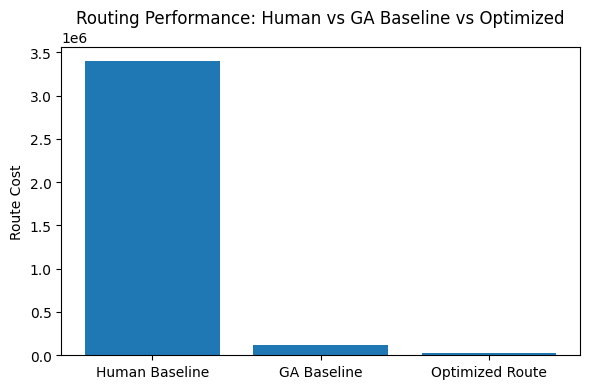

In [104]:
plt.figure(figsize=(6,4))
plt.bar(
    ["Human Baseline", "GA Baseline", "Optimized Route"],
    [human_cost, ga_baseline_cost, opt_cost]
)
plt.ylabel("Route Cost")
plt.title("Routing Performance: Human vs GA Baseline vs Optimized")
plt.tight_layout()
plt.show()


# Rota Davranışı Karşılaştırması

Rota davranışlarının görsel analizi, sayısal sonuçların nedenlerini desteklemektedir. İnsan benzeri senaryoda dağınık ve düzensiz bir ziyaret deseni gözlemlenirken, GA tabanlı fakat rota farkındalığı olmayan senaryoda sık fakat zone geçişli bir hareket yapısı ortaya çıkmaktadır. Önerilen zone farkındalıklı rota yaklaşımı ise blok bazlı, yapılandırılmış ve düşük maliyetli bir hareket deseni sergilemektedir.

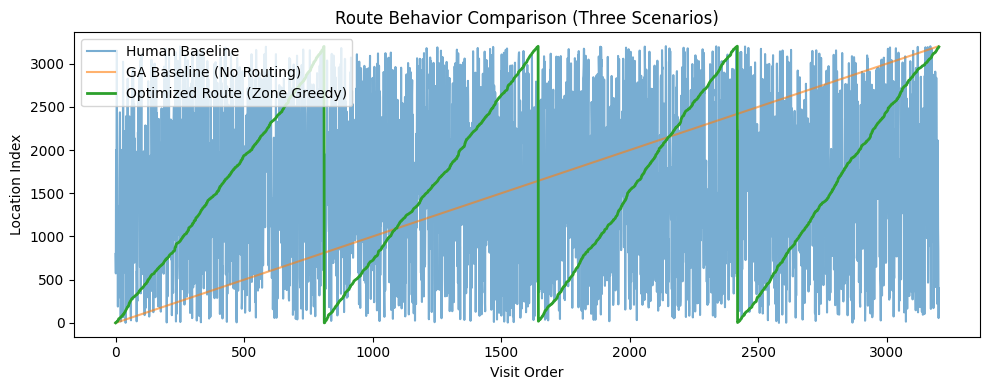

In [105]:
plt.figure(figsize=(10,4))

plt.plot(
    [best_chrom[i] for i in human_route],
    label="Human Baseline",
    alpha=0.6
)

plt.plot(
    [best_chrom[i] for i in ga_baseline_route],
    label="GA Baseline (No Routing)",
    alpha=0.6
)

plt.plot(
    [best_chrom[i] for i in opt_route],
    label="Optimized Route (Zone Greedy)",
    linewidth=2
)

plt.xlabel("Visit Order")
plt.ylabel("Location Index")
plt.title("Route Behavior Comparison (Three Scenarios)")
plt.legend()
plt.tight_layout()
plt.show()


# GA Hiperparametre Duyarlılık Analizi (Mutation Rate)

Genetik Algoritmanın evrimsel arama davranışını değerlendirmek amacıyla, mutasyon oranı için bir duyarlılık analizi gerçekleştirilmiştir. Her mutasyon oranı değeri için birden fazla bağımsız koşum yapılmış; ortalama amaç fonksiyonu değeri ve standart sapma hesaplanmıştır.

Sonuçlar, düşük mutasyon oranlarında algoritmanın erken yerel minimumlara kilitlendiğini ve yüksek varyans sergilediğini göstermektedir. Orta düzey mutasyon oranlarında (0.2–0.3 aralığı), hem çözüm kalitesi artmış hem de varyans azalmıştır. Daha yüksek mutasyon oranlarında ise ortalama maliyet bir miktar düşmesine rağmen kararlılığın azaldığı gözlemlenmiştir. Bu bulgular, keşif–yoğunlaşma dengesi açısından orta düzey mutasyon oranlarının daha uygun olduğunu göstermektedir.

In [106]:
def sensitivity_mutation_rate(
    rates=[0.01, 0.05, 0.2, 0.3,0.4],
    runs=10
):
    results = {}

    for r in rates:
        costs = []
        for seed in range(runs):
            _, cost, _, _ = genetic_algorithm_stage1_np(
                mutation_rate=r,
                seed=seed
            )
            costs.append(cost)

        results[r] = (np.mean(costs), np.std(costs))

    return results
    
mutation_results = sensitivity_mutation_rate()
mutation_results


{0.01: (np.float64(1510918.524642501), np.float64(13934.457769733763)),
 0.05: (np.float64(1489675.2781753808), np.float64(7511.606361693529)),
 0.2: (np.float64(1478796.9516335635), np.float64(4724.208683818766)),
 0.3: (np.float64(1476387.6171919305), np.float64(4306.845956367825)),
 0.4: (np.float64(1469780.9102815452), np.float64(5344.0281240581635))}

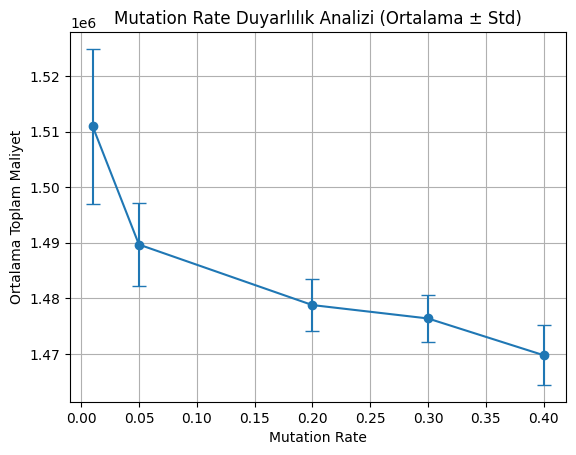

In [127]:
rates = list(mutation_results.keys())
mean_costs = [mutation_results[r][0] for r in rates]
std_costs  = [mutation_results[r][1] for r in rates]
plt.figure()
plt.errorbar(
    rates,
    mean_costs,
    yerr=std_costs,
    marker='o',
    capsize=5
)
plt.xlabel("Mutation Rate")
plt.ylabel("Ortalama Toplam Maliyet")
plt.title("Mutation Rate Duyarlılık Analizi (Ortalama ± Std)")
plt.grid(True)
plt.show()


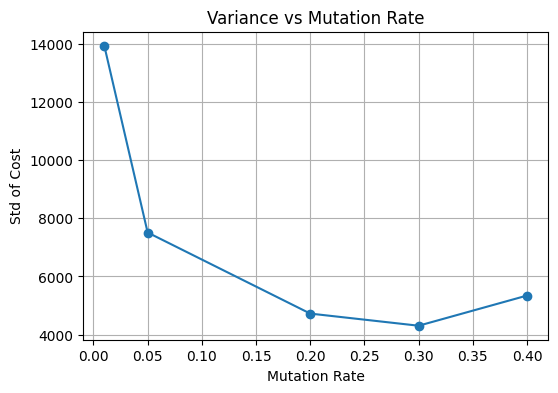

In [128]:
plt.figure(figsize=(6,4))
plt.plot(rates, stds, marker='o')
plt.xlabel("Mutation Rate")
plt.ylabel("Std of Cost")
plt.title("Variance vs Mutation Rate")
plt.grid(True)
plt.show()


# Fitness Ağırlık Duyarlılığı (Zone Transition Weight)

Bu analizde, amaç fonksiyonunda yer alan zone geçiş cezasının ağırlığı değiştirilerek çözüm kalitesi üzerindeki etkisi incelenmiştir. Elde edilen sonuçlar, ceza ağırlığı arttıkça çözüm kalitesinin belirgin biçimde bozulduğunu ortaya koymaktadır.

Orta düzey ağırlıklar arama sürecini yönlendirici bir rol oynarken, aşırı yüksek ağırlıklar çözüm uzayını ciddi biçimde daraltmakta ve optimizasyon performansını düşürmektedir. Bu durum, ceza terimlerinin yalnızca kısıt uygulama aracı değil, aynı zamanda arama uzayının geometrisini şekillendiren aktif bileşenler olduğunu göstermektedir.

In [108]:
def sensitivity_zone_weight(
    weights=[100, 200, 400, 800],
    runs=8
):
    results = {}

    for w in weights:
        def fitness_tmp(chrom):
            return (
                weighted_distance_cost_np(chrom)
                + 50.0 * zone_dispersion_penalty_np(chrom)
                + w * expected_zone_transition_penalty_np(chrom)
            )

        costs = []
        for seed in range(runs):
            np.random.seed(seed)
            random.seed(seed)

            pop = init_population(30)
            best = min(pop, key=fitness_tmp)
            best_cost = fitness_tmp(best)
            for _ in range(50):
                pop = [
                    mutate( crossover(tournament(pop), tournament(pop)),0.1)
                    for _ in range(30)
                ]
                gen_best = min(pop, key=fitness_tmp)
                gen_cost = fitness_tmp(gen_best)
                if gen_cost < best_cost:
                    best, best_cost = gen_best, gen_cost
            costs.append(best_cost)


        results[w] = (np.mean(costs), np.std(costs))

    return results


In [109]:
zone_weight_results = sensitivity_zone_weight()
zone_weight_results


{100: (np.float64(1474409.832024436), np.float64(7550.53483236239)),
 200: (np.float64(1521360.6321440525), np.float64(7797.073995947374)),
 400: (np.float64(1614921.1519429968), np.float64(8974.448474864234)),
 800: (np.float64(1800023.9881103905), np.float64(11532.880724566237))}

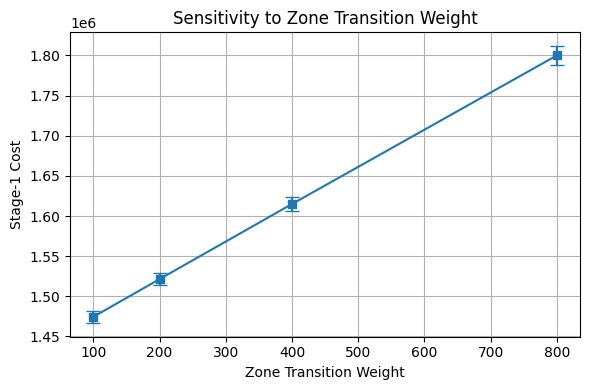

In [110]:
w = list(zone_weight_results.keys())
mean = [zone_weight_results[x][0] for x in w]
std  = [zone_weight_results[x][1] for x in w]

plt.figure(figsize=(6,4))
plt.errorbar(w, mean, yerr=std, fmt='s-', capsize=5)
plt.xlabel("Zone Transition Weight")
plt.ylabel("Stage-1 Cost")
plt.title("Sensitivity to Zone Transition Weight")
plt.grid(True)
plt.tight_layout()
plt.show()


# Genel Değerlendirme

Bu çalışmada, GA tabanlı slotting yaklaşımının depo yerleşimini iyileştirdiği; ancak asıl operasyonel kazanımın, yerleşim kararlarının zone farkındalıklı rota stratejileri ile birlikte ele alınması durumunda elde edildiği gösterilmiştir. Ayrıca gerçekleştirilen duyarlılık analizleri, önerilen optimizasyon çerçevesinin hem evrimsel hiperparametrelere hem de uygunluk ağırlıklandırmalarına karşı geniş bir kararlılık bölgesine sahip olduğunu ortaya koymaktadır. Bu özellik, yöntemin pratik depo uygulamaları için uygun ve güvenilir bir çözüm sunduğunu göstermektedir.